# SimonResearch · Expanded Signals and Holding Strategy

This experiment keeps the **stock universe and price scope from `Data.ipynb`** and expands the price/volume signals across six literature-motivated families. The recorded feature schema determines the number of raw features and daily percentile inputs. Model settings and forecast weights are selected using 2023 validation, then frozen for the $1 million long-only holding strategy on 2024–2025.

The six added families are:

- Skipped-month six- and twelve-month momentum.
- Proximity to the 52-week high.
- Abnormal dollar volume: a 50-day rank and a 20-day log shock.
- Volume-conditioned one-day reversal.
- Recent extreme returns: MAX21 and the top-five MAX measure.
- Overnight/intraday returns, 20- and 60-day compounded histories, and their spreads.

The current-constituent universe remains exploratory. Our ultimate goal is a published paper; that later stage will revisit historical membership, data scope, novelty and untouched confirmation data.

**Run every cell in order.** Results and input counts are loaded from recorded artifacts, not entered manually.

## 1. Use the research environment

From the **SimonResearch checkout**, install the model dependencies and launch Jupyter with its interpreter:

```bash
python3.12 -m venv .venv
.venv/bin/python -m pip install -r requirements-showcase.txt notebook
.venv/bin/python -m jupyter notebook notebooks/SimonResearch_Showcase.ipynb
```

Select the kernel from this environment. The experiment can also run directly with `.venv/bin/python scripts/run_showcase.py --feature-set alpha`. The first run may download the notebook's price snapshot and train the models; subsequent runs reuse the saved snapshot and artifacts. `--refresh-data` intentionally changes the snapshot, and `--retrain` reruns fitting.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

# Notebook works when opened from the repo root or the notebooks directory.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "scripts" / "run_showcase.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from the SimonResearch checkout.")
REPORT_DIR = ROOT / "reports" / "alpha"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Repository:", ROOT)
print("Python:", sys.executable)


Repository: /Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch
Python: /Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/.venv/bin/python


## 2. Build or reuse the expanded experiment

The run keeps stock observations together by date: **train eligible rows through 2022, validation 2023, test 2024–2025**, with boundary-crossing labels purged. Longer feature lookbacks can delay the first eligible training row; the saved split table below shows the actual dates. Targets remain next-day return ranks, with the same candidate model groups. The test window is exploratory development data after repeated experiments, rather than an untouched paper confirmation set.

The default command uses `--feature-set alpha` and reuses completed artifacts. Set both `REBUILD_FEATURES = True` and `RETRAIN = True` to rebuild features and fit a new model experiment; rebuilding features requires retraining to keep provenance aligned. Changes to `ITERATIONS` or `THREADS` affect fitting only when retraining. Leave `REFRESH_DATA = False` to preserve the raw price snapshot.

A deliberate rebuild and fit from the terminal is:

```bash
.venv/bin/python scripts/run_showcase.py --feature-set alpha --rebuild-features --retrain
```

The alpha experiment writes to `reports/alpha` and `models/alpha`; the original showcase artifacts remain available separately.

In [2]:
FEATURE_SET = "alpha"
RETRAIN = False
REBUILD_FEATURES = False
REFRESH_DATA = False
ITERATIONS = 500
THREADS = 4

# The default reuses the alpha snapshot, fitted model and recorded experiment.
command = [sys.executable, str(ROOT / "scripts" / "run_showcase.py"),
           "--feature-set", FEATURE_SET]
if RETRAIN:
    command.extend(["--retrain", "--iterations", str(ITERATIONS), "--threads", str(THREADS)])
if REBUILD_FEATURES:
    command.append("--rebuild-features")
if REFRESH_DATA:
    command.append("--refresh-data")
subprocess.run(command, cwd=ROOT, check=True)


Loading the prepared research feature snapshot.


Snapshot: 1,083,939 signal rows, 498 securities. Train 712,325; validation 122,255; test 248,377.
Resuming the saved, validation-selected model without refitting.
Reusing the complete frozen forecast table; trading rules do not refit the model.


Evaluating ensemble: persistent top20 long only on 2024–2025.


Evaluating elastic_net: persistent top20 long only on 2024–2025.


Evaluating xgb_regression: persistent top20 long only on 2024–2025.


...

Evaluating reversal: persistent top20 long only on 2024–2025.


Evaluating momentum: persistent top20 long only on 2024–2025.


Evaluating notebook_baseline: persistent top20 long only on 2024–2025.



Report: /Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/reports/alpha/index.html
Selected on validation: {'elastic_net': 0.25, 'xgb_regression': 0.25, 'xgb_ranker': 0.25, 'catboost': 0.25}
Test rank IC: 0.0283; gross return: 70.95%; net return: 70.95%; net Sharpe: 1.83
Initial capital: $1,000,000; ending net equity: $1,709,546.
Resolved sessions: 501/501; costs: 0 bps per side.


CompletedProcess(args=['/Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/.venv/bin/python', '/Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/scripts/run_showcase.py', '--feature-set', 'alpha'], returncode=0)

## 3. Inspect provenance and model selection

These values come from saved experiment artifacts. Changing the data snapshot or fitting settings produces a different recorded experiment.

In [3]:
import pandas as pd
from IPython.display import display, HTML, SVG

summary = json.loads((REPORT_DIR / "summary.json").read_text())
leaderboard = pd.read_csv(REPORT_DIR / "leaderboard.csv")
daily = pd.read_csv(REPORT_DIR / "daily.csv")
top_predictions = pd.read_csv(REPORT_DIR / "top_predictions.csv")
feature_importance = pd.read_csv(REPORT_DIR / "feature_importance.csv")
model_daily_path = REPORT_DIR / "model_daily.csv"
model_daily = pd.read_csv(model_daily_path) if model_daily_path.exists() else pd.DataFrame()

display(pd.DataFrame(summary["splits"]).T)
display(pd.Series(summary["dataset"], name="Dataset provenance"))
print("Experiment:", summary["experiment_id"])
print("Frozen selected forecast weights:")
display(pd.Series(summary.get("training", {}).get("selected_weights", {}), dtype="float64"))

from src.reporting.showcase import feature_input_counts
display(pd.Series(feature_input_counts(summary), name="Recorded model input counts"))


,start,end,rows,labeled_rows,dates
train,2017-01-03,2022-12-29,712325,712313,1509
validation,2023-01-03,2023-12-28,122255,122255,249
test,2024-01-02,2025-12-31,248377,247879,502


snapshot_created_at                                     2026-10-06T23:58:09.384708-05:00
source                                 https://en.wikipedia.org/wiki/List_of_S%26P_50...
price_source                                              Yahoo Finance through yfinance
requested_start                                                               2016-01-01
requested_end_exclusive                                                       2026-01-01
start                                                                         2016-01-04
end                                                                           2025-12-31
rows                                                                             1083939
quote_rows                                                                       1264542
tickers                                                                              498
requested_tickers                                                                    503
unavailable_tickers  

Experiment: 6160a36738de
Frozen selected forecast weights:


elastic_net       0.25
xgb_regression    0.25
xgb_ranker        0.25
catboost          0.25
dtype: float64

raw            24
percentiles    24
total          48
Name: Recorded model input counts, dtype: int64

## 4. The $1 million long-only holding strategy

The current strategy starts with **$1,000,000** and uses the frozen validation-selected forecast to rank each closing cross-section. It invests all available free cash across the **top 20 stocks**, adding to existing positions. Holdings remain while ranked in the **top 100**, so the portfolio can contain more than 20 names. A closing threshold breach schedules an exit for the **next trading session**, avoiding a same-day fill based on that closing rank.

Filled exits release cash available at the fill-day close, funding new entries on the following session. There are no short positions in the current run. Each individual model, the blend and every baseline is evaluated under the same recorded strategy; the full comparison remains visible even when one model's performance cannot be resolved. The saved **long_fraction**, entry and hold thresholds below are authoritative for archived experiments, which may use the earlier long/short policy.

Fills use a next-session **adjusted OHLC4 proxy**, **(Open + High + Low + Close) / 4 × Adj Close / Close**, for consistent synthetic adjusted-price/unit accounting. This is not a guaranteed executable quote and does not claim actual cash-dividend accounting. Costs are read from the recorded evaluation. When commission and borrowing settings are both zero, the report shows one selected NAV curve with these costs excluded; nonzero-cost runs retain before/after comparison.


The optional TabPFN-3.5 row reports its completion status. A pilot has no full-period return, Sharpe or drawdown; see `docs/tabpfn.md` for its context, API usage and batch check.


In [4]:
from src.reporting.showcase import costs_are_zero

evaluation = summary.get("evaluation", {})
cost_free = costs_are_zero(evaluation)
result_fields = ["strategy_name", "initial_capital", "final_net_equity",
                 "net_cumulative_return", "annualized_sharpe", "max_drawdown",
                 "cost_bps", "annual_borrow_bps", "long_fraction", "entry_k", "exit_k",
                 "start_date", "first_execution_date", "trading_dates", "aggregate_resolved_dates"]
if not cost_free:
    result_fields[2:2] = ["final_gross_equity", "gross_cumulative_return"]
labels = {
    "initial_capital": "Initial capital",
    "final_net_equity": "Ending NAV" if cost_free else "Ending NAV after costs",
    "final_gross_equity": "Ending NAV before costs",
    "net_cumulative_return": "Return" if cost_free else "Net return",
    "gross_cumulative_return": "Gross return",
    "annualized_sharpe": "Sharpe" if cost_free else "Net Sharpe",
    "max_drawdown": "Max drawdown",
    "cost_bps": "Commission (bps per side)",
    "annual_borrow_bps": "Borrow fee (bps per year)",
}
display(pd.Series({labels.get(key, key): evaluation[key] for key in result_fields if key in evaluation},
                  name="Recorded strategy results — costs excluded" if cost_free else "Recorded strategy results"))
nav_columns = [key for key in ["Date", "net_nav"] if key in daily] if cost_free else [
    key for key in ["Date", "gross_nav", "net_nav"] if key in daily]
if {"gross_nav", "net_nav"}.issubset(daily.columns):
    endpoints = daily[nav_columns].iloc[[0, -1]]
    display(endpoints.rename(columns={"net_nav": "NAV"}) if cost_free else endpoints)
else:
    print("These artifacts use the archived intraday strategy; rerun the updated strategy command.")

# Always retain every model, blend and baseline, including unresolved rows.
from src.reporting.showcase import model_name
comparison_columns = [column for column in [
    "model", "cumulative_net_return", "sharpe_net", "max_drawdown_net",
    "final_net_equity", "status", "failure"] if column in leaderboard]
comparison_table = leaderboard[comparison_columns].copy()
if "model" in comparison_table:
    comparison_table["model"] = comparison_table["model"].map(model_name)
display(comparison_table.rename(columns={
    "model": "Model", "cumulative_net_return": "Return",
    "sharpe_net": "Sharpe", "max_drawdown_net": "Max drawdown",
    "final_net_equity": "Ending NAV", "status": "Status", "failure": "Unresolved reason",
}))
print("Return and drawdown are decimal fractions. Missing performance metrics are unresolved or invalid, not zero.")


strategy_name                rank_hold_long_only
Initial capital                        1000000.0
Ending NAV                        1709546.024289
Return                                  0.709546
Sharpe                                  1.834866
Max drawdown                           -0.087923
Commission (bps per side)                    0.0
Borrow fee (bps per year)                    0.0
long_fraction                                1.0
entry_k                                       20
exit_k                                       100
start_date                            2024-01-02
first_execution_date                  2024-01-03
trading_dates                                501
aggregate_resolved_dates                     501
Name: Recorded strategy results — costs excluded, dtype: object

,Date,NAV
0,2024-01-02,1.000000e+06
501,2025-12-31,1.709546e+06


,Model,Return,Sharpe,Max drawdown,Ending NAV,Status,Unresolved reason
0,Blend,0.709546,1.834866,-0.087923,1.709546e+06,resolved,NaN
1,Elastic Net,0.737623,1.679965,-0.122689,1.737623e+06,resolved,NaN
2,XGBoost regression,0.564215,1.280012,-0.186271,1.564215e+06,resolved,NaN
3,XGBoost Ranker,0.662284,1.876979,-0.115492,1.662284e+06,resolved,NaN
4,CatBoost,0.713805,1.645862,-0.128102,1.713805e+06,resolved,NaN
5,Reversal baseline,0.501903,1.526350,-0.081253,1.501903e+06,resolved,NaN
6,Momentum baseline,1.816810,1.898413,-0.266667,2.816810e+06,resolved,NaN
7,Original-feature baseline,0.399355,1.434693,-0.103077,1.399355e+06,resolved,NaN
8,TabPFN-3.5,NaN,NaN,NaN,NaN,pilot_only,API pilot succeeded. The predeclared batch-ind...


Return and drawdown are decimal fractions. Missing performance metrics are unresolved or invalid, not zero.


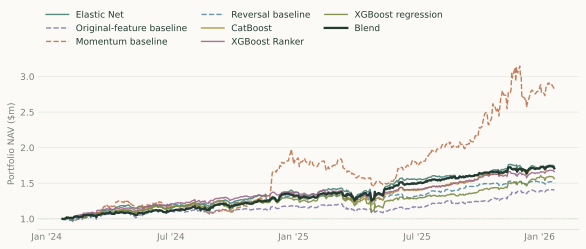

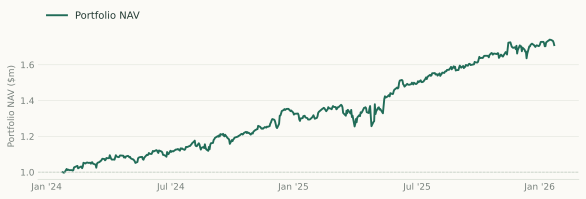

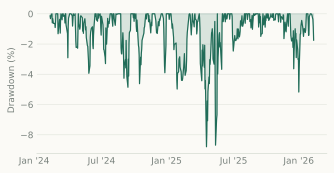

In [5]:
def show_figure(name):
    path = REPORT_DIR / "figures" / f"{name}.svg"
    if path.exists():
        display(SVG(filename=str(path)))
    else:
        print(f"No exported {name} figure for this experiment.")

# All complete individual-model, blend and baseline paths are shown together.
show_figure("model_comparison")
# The blend / selected forecast also retains its standalone NAV chart.
show_figure("strategy_equity")
show_figure("drawdown_net")


## 5. Look inside the model

The importance chart describes the fitted models; it does not identify a causal economic mechanism. The exported prediction snapshot is a historical demonstration, not a live trade instruction. Predicted returns are decimals, while the selected model's rank score measures relative cross-sectional ordering.

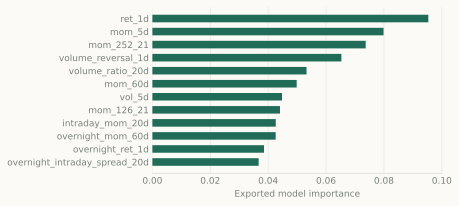

,feature,importance
0,ret_1d,0.095341
1,mom_5d,0.079871
2,mom_252_21,0.073703
3,volume_reversal_1d,0.065299
4,volume_ratio_20d,0.053255
5,mom_60d,0.049861
6,vol_5d,0.044793
7,mom_126_21,0.044091
8,intraday_mom_20d,0.042633
9,overnight_mom_60d,0.042594


,Date,Ticker,rank,score,prediction,disagreement
0,2025-12-31,NEM,1,0.975855,0.000887,0.011617
1,2025-12-31,HOOD,2,0.957746,0.000887,0.075141
2,2025-12-31,VTR,3,0.957746,0.000887,0.017073
3,2025-12-31,PLTR,4,0.955734,0.000887,0.041626
4,2025-12-31,APP,5,0.953722,0.000887,0.051429
5,2025-12-31,SMCI,6,0.953722,0.000887,0.088531
6,2025-12-31,CIEN,7,0.950704,0.000887,0.041739
7,2025-12-31,VLO,8,0.933602,0.000887,0.024806
8,2025-12-31,INTC,9,0.923541,0.000887,0.052417
9,2025-12-31,GLW,10,0.917505,0.000887,0.009857


In [6]:
show_figure("feature_importance")
display(feature_importance)
if "Date" in top_predictions:
    parsed_dates = pd.to_datetime(top_predictions["Date"], errors="coerce")
    snapshot = top_predictions.loc[parsed_dates.eq(parsed_dates.max())]
else:
    snapshot = top_predictions
if "rank" in snapshot:
    snapshot = snapshot.sort_values("rank")
display(snapshot.head(10))


## 6. Open the showcase and preserve the research trail

`reports/alpha/index.html` is a self-contained dashboard with no network dependencies. Its SVG and PNG figures can be reused in a club presentation. `summary.json` retains the snapshot hash, dates, model selection metadata and limitations; the CSVs retain the actual observations behind the display.

Our eventual paper plan is recorded in `docs/research-roadmap.md`. After this demo, we can investigate a specific model behavior, reproduce the relevant literature, expand the data appropriately, and reserve a new confirmation evaluation.

In [7]:
dashboard = REPORT_DIR / "index.html"
print("Dashboard:", dashboard)
display(HTML(dashboard.read_text()))
print("Recorded limitations:")
for item in summary.get("limitations", []):
    print("•", item)


Dashboard: /Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/reports/alpha/index.html


Model,Return,Sharpe,Max drawdown,Ending NAV,Status
Blend,71.0%,1.83,-8.8%,"$1,709,546",Resolved
Elastic Net,73.8%,1.68,-12.3%,"$1,737,623",Resolved
XGBoost regression,56.4%,1.28,-18.6%,"$1,564,215",Resolved
XGBoost Ranker,66.2%,1.88,-11.5%,"$1,662,284",Resolved
CatBoost,71.4%,1.65,-12.8%,"$1,713,805",Resolved
Reversal baseline,50.2%,1.53,-8.1%,"$1,501,903",Resolved
Momentum baseline,181.7%,1.90,-26.7%,"$2,816,810",Resolved
Original-feature baseline,39.9%,1.43,-10.3%,"$1,399,355",Resolved
TabPFN-3.5,—,—,—,—,Pilot only


Recorded limitations:
• The Wikipedia universe is current at download time; historical results have survivorship and future-membership selection bias.
• The Yahoo Finance snapshot is not point-in-time institutional data; adjusted history can be revised.
• OHLC4 is a hypothetical full-day execution proxy, not VWAP or a guaranteed attainable fill. Orders use only prior-session information.
• Adjusted total-return units approximate corporate actions; actual dividend cash timing and verified split-share inventories are not modeled.
• The fixed next-day forecast target and a multi-day ranking exit strategy have different holding horizons.
• Configured transaction and borrow fees are simplified; a zero-fee run excludes trading costs. Market impact, volume participation limits and spread variation are unmodeled. Ending equity includes open positions without terminal liquidation fees.
• Literature-motivated daily feature formulas adapt published signals; no published alpha magnitude is assumed